# EGX EDA

This notebook performs the initial exploratory data analysis for the five EGX stocks used in the project. It downloads the raw OHLCV data, validates the files, studies return behavior and correlations, and summarizes price-volume structure.

The layout follows the same style as the feature-engineering notebook: short section headers, focused code cells, and clear commentary around each analytical block.

## 1. Setup and Data Acquisition

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [2]:
TICKERS = ["COMI.CA", "HRHO.CA", "TMGH.CA", "SWDY.CA", "ORWE.CA"]
START = "2019-01-01"
RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)


def download_egx_history(ticker: str, start: str = START) -> pd.DataFrame:
    """Download one ticker from Yahoo Finance and return a cleaned daily OHLCV frame."""
    frame = yf.download(ticker, start=start, auto_adjust=True)
    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = frame.columns.get_level_values(0)
    frame = frame.dropna()
    frame = frame.loc[frame["Volume"] > 0].copy()
    return frame


for ticker in TICKERS:
    history = download_egx_history(ticker)
    output_path = RAW_DIR / f"{ticker.replace('.', '_')}.csv"
    history.to_csv(output_path)
    print(f"{ticker}: {len(history)} rows -> saved to {output_path}")

[*********************100%***********************]  1 of 1 completed


COMI.CA: 1759 rows -> saved to ..\data\raw\COMI_CA.csv


[*********************100%***********************]  1 of 1 completed


HRHO.CA: 1759 rows -> saved to ..\data\raw\HRHO_CA.csv


[*********************100%***********************]  1 of 1 completed


TMGH.CA: 1763 rows -> saved to ..\data\raw\TMGH_CA.csv


[*********************100%***********************]  1 of 1 completed


SWDY.CA: 1761 rows -> saved to ..\data\raw\SWDY_CA.csv


[*********************100%***********************]  1 of 1 completed

ORWE.CA: 1762 rows -> saved to ..\data\raw\ORWE_CA.csv


## 2. Sanity Checks

In [3]:
def summarize_raw_file(ticker: str) -> None:
    """Print a compact integrity summary for one saved raw CSV file."""
    path = RAW_DIR / f"{ticker.replace('.', '_')}.csv"
    frame = pd.read_csv(path, index_col="Date", parse_dates=True)
    print(f"\n{ticker}")
    print(f"  Rows      : {len(frame)}")
    print(f"  Date range : {frame.index[0].date()} -> {frame.index[-1].date()}")
    print(f"  Columns   : {list(frame.columns)}")
    print(f"  Nulls     : {int(frame.isna().sum().sum())}")
    print(f"  Sample    :\n{frame.tail(3)}")


for ticker in TICKERS:
    summarize_raw_file(ticker)


COMI.CA
  Rows      : 1759
  Date range : 2019-01-02 -> 2026-07-01
  Columns   : ['Close', 'High', 'Low', 'Open', 'Volume']
  Nulls     : 0
  Sample    :
                 Close        High         Low        Open   Volume
Date                                                               
2026-06-29  126.889999  130.300003  126.209999  129.820007  5226945
2026-06-30  127.500000  129.940002  126.889999  126.889999  4160115
2026-07-01  127.300003  128.449997  127.250000  127.500000  2459727

HRHO.CA
  Rows      : 1759
  Date range : 2019-01-02 -> 2026-07-01
  Columns   : ['Close', 'High', 'Low', 'Open', 'Volume']
  Nulls     : 0
  Sample    :
                Close       High        Low       Open   Volume
Date                                                           
2026-06-29  26.520000  26.610001  26.090000  26.400000  1762570
2026-06-30  26.700001  26.799999  26.389999  26.520000  2300623
2026-07-01  26.830000  27.100000  26.620001  26.700001  2572122

TMGH.CA
  Rows      : 1763
  

In [4]:
DATA_DIR = RAW_DIR
TICKER_FILES = {ticker: f"{ticker.replace('.', '_')}.csv" for ticker in TICKERS}


def load_stock_panel() -> dict[str, pd.DataFrame]:
    """Load each raw CSV into a cleaned OHLCV DataFrame keyed by ticker."""
    stock_frames: dict[str, pd.DataFrame] = {}
    for ticker, filename in TICKER_FILES.items():
        frame = pd.read_csv(DATA_DIR / filename, index_col="Date", parse_dates=True).sort_index()
        frame = frame.loc[:, ["Close", "High", "Low", "Open", "Volume"]].dropna()
        stock_frames[ticker] = frame
    return stock_frames


stock_data = load_stock_panel()
log_returns = pd.DataFrame(
    {
        ticker: np.log(frame["Close"] / frame["Close"].shift(1))
        for ticker, frame in stock_data.items()
    }
).dropna()

display(log_returns.head())
print(f"Combined daily log returns shape: {log_returns.shape}")

,COMI.CA,HRHO.CA,TMGH.CA,SWDY.CA,ORWE.CA
Date,,,,,
2019-01-03,0.004994,-0.003286,0.008768,-0.013393,0.014665
2019-01-06,0.002749,0.006562,-0.000970,0.000562,0.008156
2019-01-08,-0.012364,0.031544,0.016370,0.032591,0.000000
2019-01-09,-0.014262,0.015718,0.030106,0.000000,-0.002711
2019-01-10,-0.005384,0.009314,0.005545,0.009197,-0.001811


Combined daily log returns shape: (1744, 5)


## 3. Daily Returns and Volatility

,Annualized Volatility
SWDY.CA,0.424101
TMGH.CA,0.413264
ORWE.CA,0.368986
HRHO.CA,0.360675
COMI.CA,0.300648


Annualized volatility, sorted from highest to lowest:
SWDY.CA: 42.41%
TMGH.CA: 41.33%
ORWE.CA: 36.90%
HRHO.CA: 36.07%
COMI.CA: 30.06%


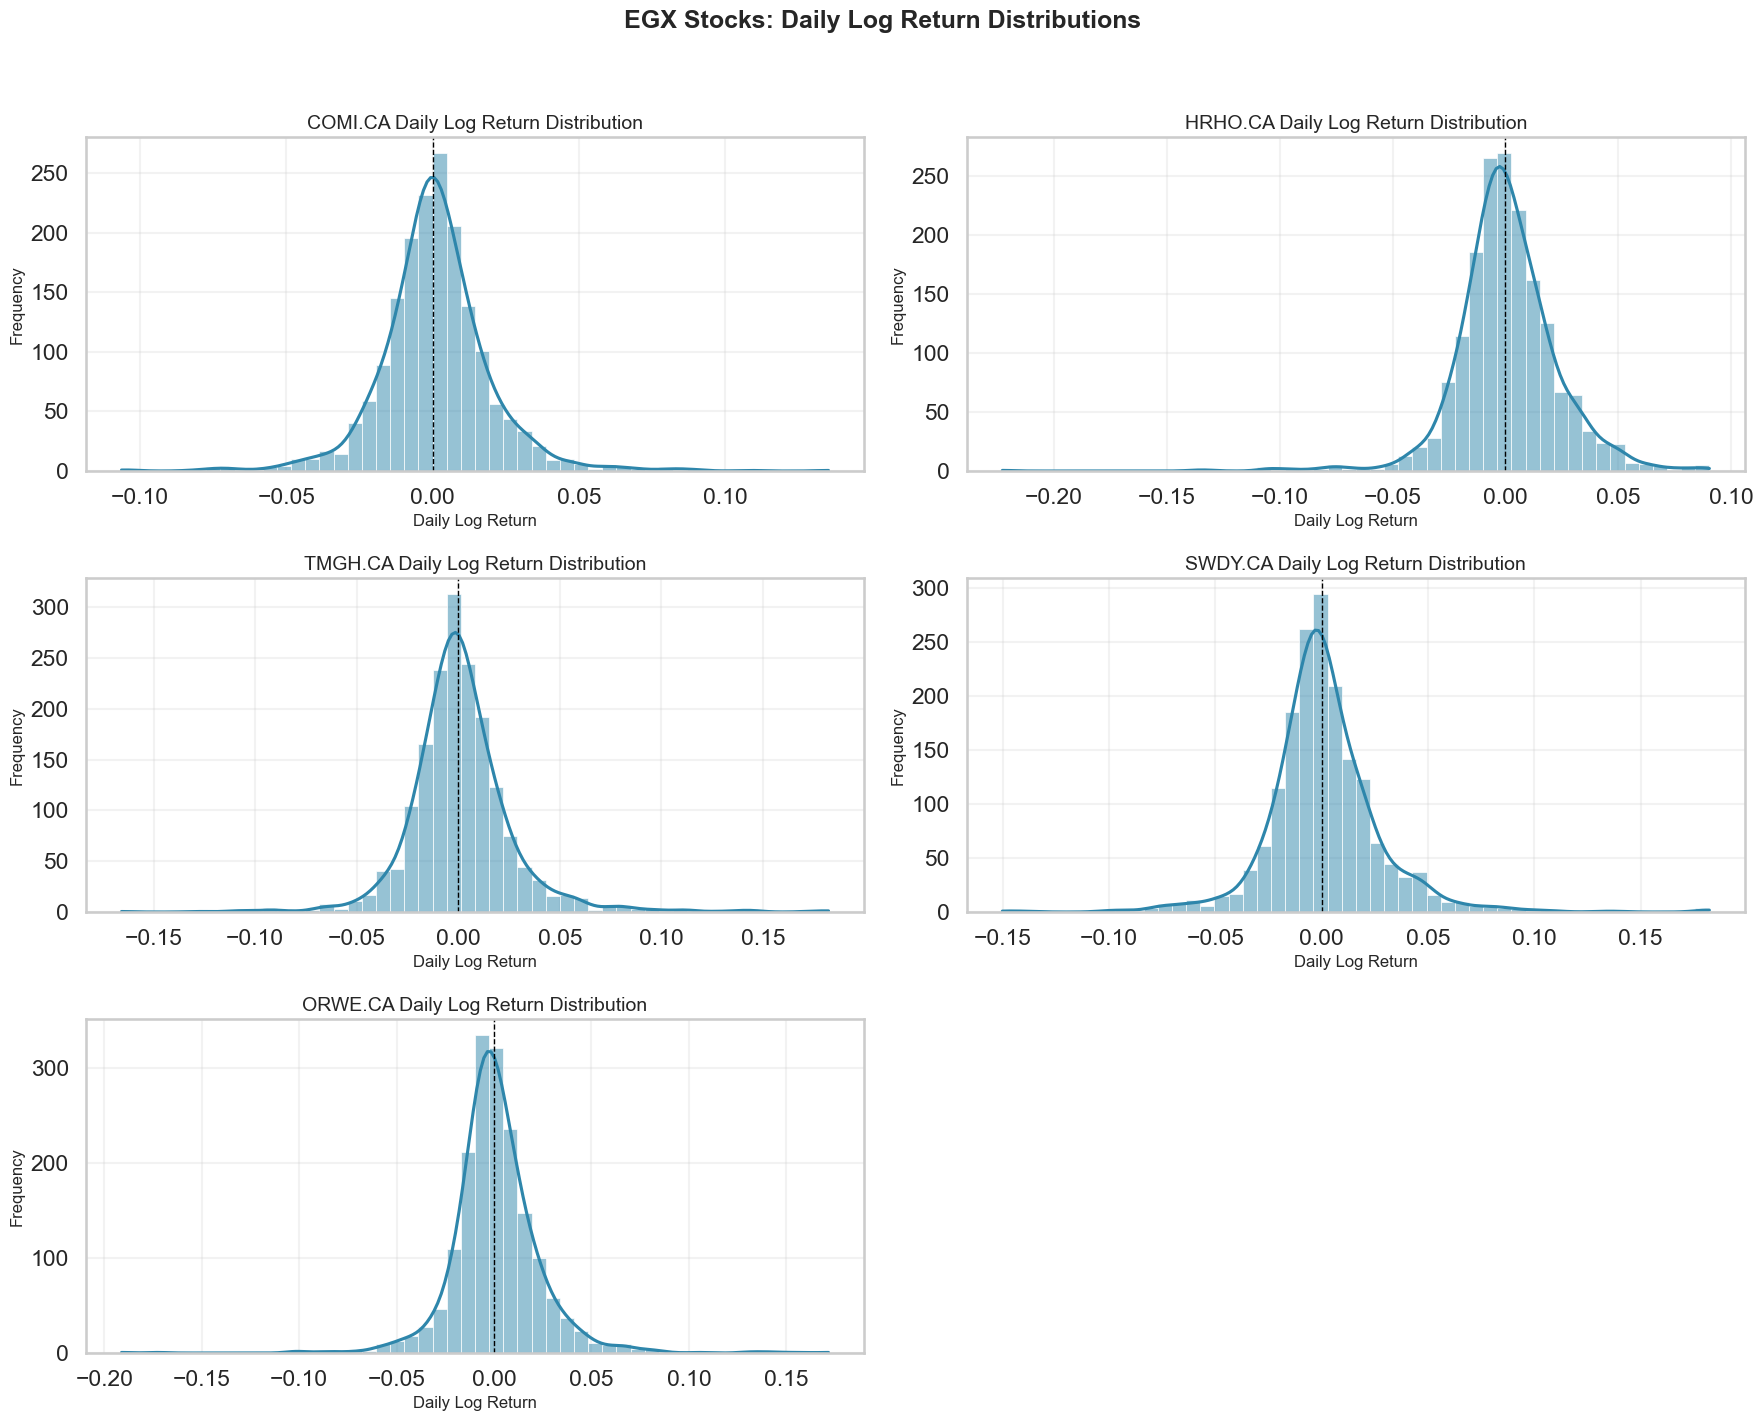

In [5]:
annualized_volatility = log_returns.std() * np.sqrt(252)
volatility_summary = annualized_volatility.sort_values(ascending=False).rename("Annualized Volatility").to_frame()

display(volatility_summary)

print("Annualized volatility, sorted from highest to lowest:")
for ticker, volatility in annualized_volatility.sort_values(ascending=False).items():
    print(f"{ticker}: {volatility:.2%}")

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for index, ticker in enumerate(TICKERS):
    sns.histplot(log_returns[ticker], bins=50, kde=True, ax=axes[index], color="#2E86AB", edgecolor="white", linewidth=0.5)
    axes[index].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[index].set_title(f"{ticker} Daily Log Return Distribution")
    axes[index].set_xlabel("Daily Log Return")
    axes[index].set_ylabel("Frequency")
    axes[index].grid(True, alpha=0.25)

for axis in axes[len(TICKERS):]:
    axis.set_visible(False)

plt.suptitle("EGX Stocks: Daily Log Return Distributions", y=1.02, fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

,COMI.CA,HRHO.CA,TMGH.CA,SWDY.CA,ORWE.CA
COMI.CA,1.000000,0.401070,0.294592,0.345549,0.344537
HRHO.CA,0.401070,1.000000,0.436545,0.439942,0.408594
TMGH.CA,0.294592,0.436545,1.000000,0.441788,0.338347
SWDY.CA,0.345549,0.439942,0.441788,1.000000,0.361383
ORWE.CA,0.344537,0.408594,0.338347,0.361383,1.000000


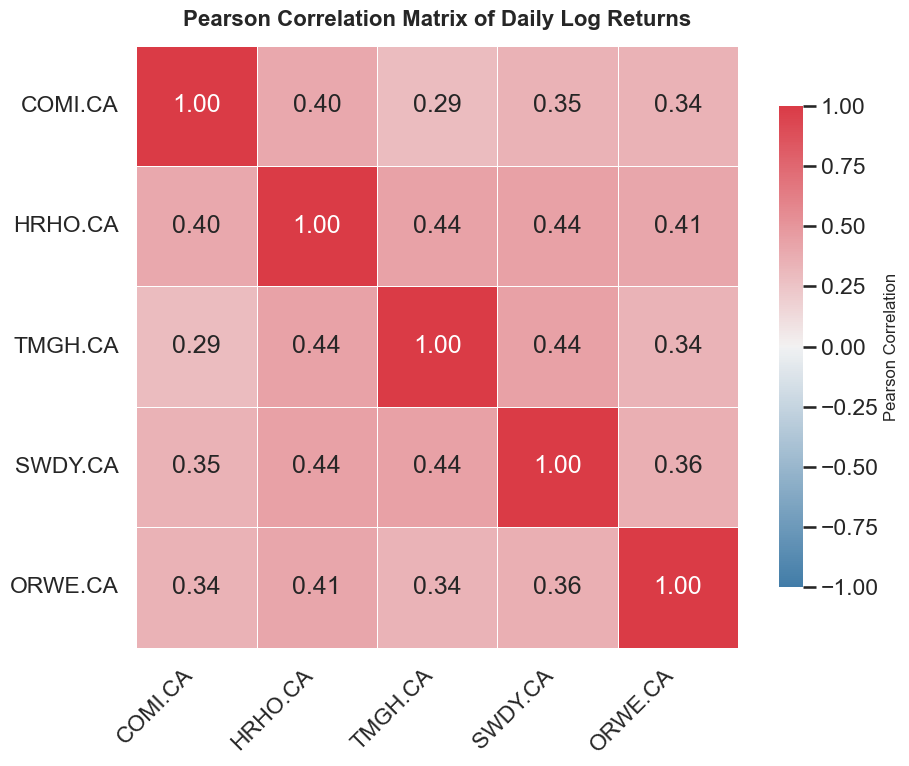

In [6]:
correlation_matrix = log_returns.corr(method="pearson")
display(correlation_matrix)

plt.figure(figsize=(10, 8))
heatmap_cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=heatmap_cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
)
plt.title("Pearson Correlation Matrix of Daily Log Returns", fontsize=16, fontweight="bold", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Price vs Volume Analysis

In [7]:
def add_volume_spike_features(stock_df: pd.DataFrame, window: int = 21, spike_multiplier: float = 2.5) -> pd.DataFrame:
    """Add daily return, rolling volume mean, and a binary volume-spike flag."""
    enriched_df = stock_df.copy()
    enriched_df["Daily_Log_Return"] = np.log(enriched_df["Close"] / enriched_df["Close"].shift(1))
    enriched_df["Volume_Rolling_21D"] = enriched_df["Volume"].rolling(window=window, min_periods=window).mean()
    enriched_df["Volume_Spike"] = enriched_df["Volume"] > (spike_multiplier * enriched_df["Volume_Rolling_21D"])
    return enriched_df


volume_analysis = {}
spike_summary_records = []

for ticker, stock_df in stock_data.items():
    enriched_df = add_volume_spike_features(stock_df)
    volume_analysis[ticker] = enriched_df

    spike_mask = enriched_df["Volume_Spike"].fillna(False)
    spike_days = int(spike_mask.sum())
    avg_spike_return = enriched_df.loc[spike_mask, "Daily_Log_Return"].mean()

    spike_summary_records.append(
        {
            "Ticker": ticker,
            "Spike Days": spike_days,
            "Average Return on Spike Days": avg_spike_return,
        }
    )

spike_summary = pd.DataFrame(spike_summary_records).set_index("Ticker")
display(spike_summary)

print("Volume spike summary:")
for ticker, row in spike_summary.iterrows():
    avg_return = row["Average Return on Spike Days"]
    avg_return_text = "N/A" if pd.isna(avg_return) else f"{avg_return:.4%}"
    print(f"{ticker}: {int(row['Spike Days'])} spike days | avg spike-day return = {avg_return_text}")

,Spike Days,Average Return on Spike Days
Ticker,,
COMI.CA,71,-0.003494
HRHO.CA,96,0.015458
TMGH.CA,108,0.020758
SWDY.CA,104,0.019986
ORWE.CA,112,0.015229


Volume spike summary:
COMI.CA: 71 spike days | avg spike-day return = -0.3494%
HRHO.CA: 96 spike days | avg spike-day return = 1.5458%
TMGH.CA: 108 spike days | avg spike-day return = 2.0758%
SWDY.CA: 104 spike days | avg spike-day return = 1.9986%
ORWE.CA: 112 spike days | avg spike-day return = 1.5229%


## 6. Summary and Key Insights

- The combined daily log-return panel provides a clean, aligned view of all 5 EGX stocks and is the right foundation for cross-asset analysis.
- The return histograms show how each ticker’s return distribution differs in spread and tail behavior, which is a practical proxy for relative risk and event sensitivity.
- Annualized volatility is the fastest way to compare risk across the basket; the highest-volatility name should be treated as the most aggressive asset in the group.
- The Pearson correlation matrix highlights whether the stocks move together or diversify one another. Higher positive correlations imply weaker diversification benefits.
- The 21-day rolling volume spike filter identifies unusually active sessions and helps isolate days where price discovery likely had stronger conviction.
- Comparing spike-day returns against the full sample can reveal whether heavy participation tends to confirm trend continuation or cluster around reversal-type events.
- Taken together, this notebook suggests a workflow for distinguishing high-risk, high-activity names from more stable stocks and for using volume confirmation as a secondary signal in modeling and trading research.